<h1> Lab 2, Task 2, Sverdlyk Ivan, FB-51mp </h1>

In [1]:
# Завантажую всі необхідні бібліотеки
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
import time

#### Завантаження зображення, квантування кольорів для кожного значення K, а також візуалізація

Original image: 600x600 (360000 pixels)
Processing K=64...
K=64 finished in 17.67 sec.
Processing K=32...
K=32 finished in 9.11 sec.
Processing K=16...
K=16 finished in 4.59 sec.
Processing K=8...
K=8 finished in 2.12 sec.
Processing K=4...
K=4 finished in 1.13 sec.


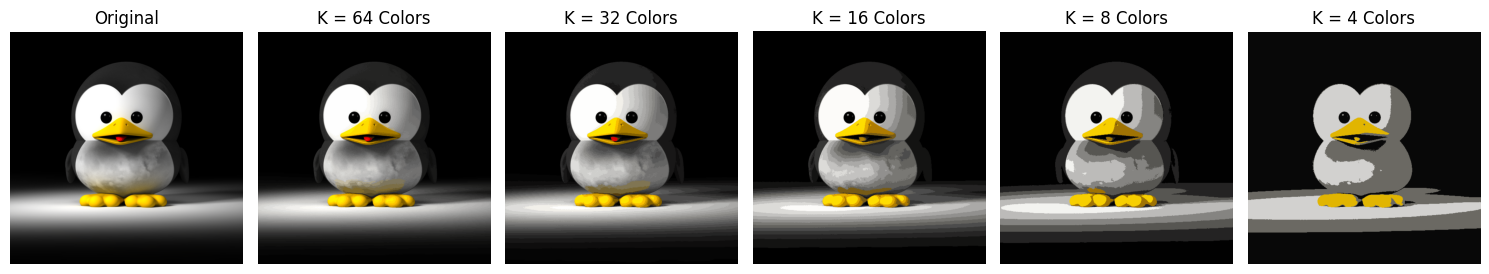

In [2]:
def quantize_image(image_path, k_values):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    height, width, channels = img_rgb.shape
    pixel_array = np.reshape(img_rgb, (height * width, channels))
    pixel_array = pixel_array / 255.0
    print(f"Original image: {width}x{height} ({height * width} pixels)")
    num_plots = len(k_values) + 1
    plt.figure(figsize=(15, 5))
    # Оригінальне зображення
    plt.subplot(1, num_plots, 1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis('off')
    # Для всіх значень
    for i, K in enumerate(k_values):
        print(f"Processing K={K}...")
        start_time = time.time()
        kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
        kmeans.fit(pixel_array)
        new_colors = kmeans.cluster_centers_
        labels = kmeans.labels_
        quantized_pixels = new_colors[labels]
        quantized_pixels = (quantized_pixels * 255).astype(np.uint8)
        quantized_image = np.reshape(quantized_pixels, (height, width, channels))
        end_time = time.time()
        print(f"K={K} finished in {end_time - start_time:.2f} sec.")
        plt.subplot(1, num_plots, i + 2)
        plt.title(f"K = {K} Colors")
        plt.imshow(quantized_image)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
image_file = 'test.jpg' 
k_levels = [64, 32, 16, 8, 4]
quantize_image(image_file, k_levels)
    